# HadISD with PyEarthTools & XGBoost
HadISD is a global sub-daily dataset based on the ISD dataset from NOAA's NCEI. As well as station selection criteria, a suite of quality control tests has been run on the major climatological variables.

For this demonstration we are using version 3.4.0.2023f of the dataset, which can be downloaded here: https://www.metoffice.gov.uk/hadobs/hadisd/v340_2023f/download.html

Before the dataset can be used, it must be converted to Zarr. Please refer to the HadISD_to_Zarr jupyter notebook for information on how to do this.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import pyearthtools.pipeline as petpipe
import pyearthtools.data as petdata
from pyearthtools.tutorial.HadisdDataClass import HadISDIndex

The following cell is used to run a pipeline configuration notebook that allows custom pipeline steps to be defined and included in the pipeline.

In [2]:
%run Pipeline_Config.ipynb

## Creating an ordered list of all available HadISD station IDs
The  HadISDIndex class contains a method called "get_alL station_ids" that can be used to create a list of all available station IDS. This list can be used to select, for example, the first_ten stations from all stations. It can then be passedto select data from within the pipeline. It's also possible to pass a single station ID as a string to retrieve data for a single station.

In [3]:
hadisd = HadISDIndex()
all_stations = hadisd.get_all_station_ids()
all_stations_ordered = sorted(all_stations)
print(f"Total number of stations: {len(all_stations_ordered)}")

Total number of stations: 0


In [4]:
# Select first n stations
first_ten_stations = all_stations_ordered[:10]
print(f"List of first ten stations:", first_ten_stations)

List of first ten stations: []


In [5]:
zarr_path = "/Users/joelmiller/HadISD_data/zarr.zarr"
ds = xr.open_zarr(zarr_path)
ds

<xarray.Dataset> Size: 42GB
Dimensions:                (station: 100, time: 473329, coordinate_length: 1,
                            flagged: 19, test: 71, reporting_v: 19,
                            reporting_t: 1116, reporting_2: 2)
Coordinates:
    elevation              (station, coordinate_length) float64 800B dask.array<chunksize=(100, 1), meta=np.ndarray>
    latitude               (station, coordinate_length) float64 800B dask.array<chunksize=(100, 1), meta=np.ndarray>
    longitude              (station, coordinate_length) float64 800B dask.array<chunksize=(100, 1), meta=np.ndarray>
  * station                (station) <U12 5kB '010010-99999' ... '013670-99999'
  * time                   (time) datetime64[ns] 4MB 1970-01-01 ... 2023-12-31
Dimensions without coordinates: coordinate_length, flagged, test, reporting_v,
                                reporting_t, reporting_2
Data variables: (12/26)
    cloud_base             (station, time) float64 379MB dask.array<chunksize=(100, 10000), meta=np.ndarray>
    dewpoints              (station, time) float64 379MB dask.array<chunksize=(100, 10000), meta=np.ndarray>
    flagged_obs            (station, time, flagged) float64 7GB dask.array<chunksize=(100, 10000, 19), meta=np.ndarray>
    high_cloud_cover       (station, time) float64 379MB dask.array<chunksize=(100, 10000), meta=np.ndarray>
    low_cloud_cover        (station, time) float64 379MB dask.array<chunksize=(100, 10000), meta=np.ndarray>
    mid_cloud_cover        (station, time) float64 379MB dask.array<chunksize=(100, 10000), meta=np.ndarray>
    ...                     ...
    stnlp                  (station, time) float64 379MB dask.array<chunksize=(100, 10000), meta=np.ndarray>
    temperatures           (station, time) float64 379MB dask.array<chunksize=(100, 10000), meta=np.ndarray>
    total_cloud_cover      (station, time) float64 379MB dask.array<chunksize=(100, 10000), meta=np.ndarray>
    wind_gust              (station, time) float64 379MB dask.array<chunksize=(100, 10000), meta=np.ndarray>
    winddirs               (station, time) float64 379MB dask.array<chunksize=(100, 10000), meta=np.ndarray>
    windspeeds             (station, time) float64 379MB dask.array<chunksize=(100, 10000), meta=np.ndarray>
Attributes: (12/39)
    Conventions:                 CF-1.6
    Metadata_Conventions:        Unidata Dataset Discovery v1.0, CF Discrete ...
    acknowledgement:             RJHD was supported by the Joint BEIS/Defra M...
    cdm_data_type:               station
    creator_email:               robert.dunn@metoffice.gov.uk
    creator_name:                Robert Dunn
    ...                          ...
    station_id:                  010010-99999
    station_information:         Where station is a composite the station id ...
    summary:                     Quality-controlled, sub-daily, station datas...
    time_coverage_end:           2023-12-31T23:00Z
    time_coverage_start:         1931-01-01T06:00Z
    title:                       HadISD

## Pre-Training Data Pipeline
- Hadisd accepts "all" as an argument to get all stations.
- A single station can also be specified, e.g., "010010-99999".
- A list of station IDs can also be passed, e.g., ["010010-99999", "010014-99999"]

To demonstarte the piepline, we will pass the list we created above called "first_ten_stations"

Many of the variables and pipeline steps below have been taken from the `Pipeline_Config.ipynb` notebook using the %run command.


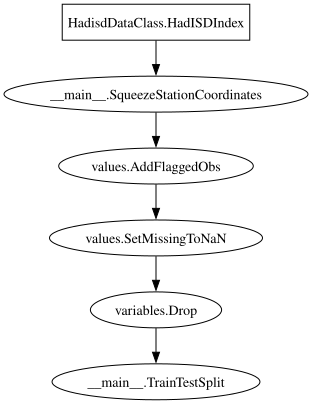

In [12]:
data_prep_pipe = petpipe.Pipeline(
    petdata.archive.hadisd(station = "all"), #, variables=["dewpoints", "flagged_obs"]), # Use all stations
    SqueezeStationCoordinates(),
    petdata.transforms.values.AddFlaggedObs(flagged_labels),
    petdata.transforms.values.SetMissingToNaN(varname_val_map),
    petdata.transforms.variables.Drop("flagged_obs"),
    TrainTestSplit(test_size=0.2, random_state=42, dim='time'),  # returns (ds_train, ds_test)
#     (
#         # branch 1: train
#         (
#             FeatureTargetSplit(target_vars="quality_control_flags"),
#             (
#                 # branch X_train
#                 (
#                     petpipe.operations.xarray.conversion.ToNumpy(),
#                     MedianImputePerStation(),
#                     TransposeAndFlattenX(),
#                 ),
#                 # branch y_train
#                 (
#                     petpipe.operations.xarray.conversion.ToNumpy(),
#                     SelectAndFlattenY(test_number=33),
#                 ),
#                 'map'
#             ),
#             FilterNaNSamples(),  # filters (X_train, y_train)
#         ),
#         # branch 2: test
#         (
#             FeatureTargetSplit(target_vars="quality_control_flags"),
#             (
#                 # branch X_test
#                 (
#                     petpipe.operations.xarray.conversion.ToNumpy(),
#                     MedianImputePerStation(),
#                     TransposeAndFlattenX(),
#                 ),
#                 # branch y_test
#                 (
#                     petpipe.operations.xarray.conversion.ToNumpy(),
#                     SelectAndFlattenY(test_number=33),
#                 ),
#                 'map'
#             ),
#             FilterNaNSamples(),  # filters (X_test, y_test)
#         ),
#         'map'
#     )
)
data_prep_pipe

In [13]:
dataset = data_prep_pipe["1969-01-01T00"] # Curretnly we have to select a date outside of the date range to select the entire dataset (fix coming soon)

/Users/joelmiller/Projects/Python/PyEarthTools_Fork/PyEarthTools/packages/data/src/pyearthtools/data/indexes/indexes.py:492: IndexWarning: Could not find time in dataset to select on. Petdt('1969-01-01T00')
  warnings.warn(


In [19]:
dataset

(<xarray.Dataset> Size: 28GB
 Dimensions:                (station: 100, time: 378663, test: 71)
 Coordinates:
   * station                (station) <U12 5kB '010010-99999' ... '013670-99999'
   * time                   (time) datetime64[ns] 3MB 2013-12-13T12:00:00 ... ...
 Dimensions without coordinates: test
 Data variables: (12/24)
     mid_cloud_cover        (station, time) float64 303MB dask.array<chunksize=(100, 9861), meta=np.ndarray>
     precip3_depth          (station, time) float64 303MB dask.array<chunksize=(100, 9861), meta=np.ndarray>
     stnlp                  (station, time) float64 303MB dask.array<chunksize=(100, 9861), meta=np.ndarray>
     precip24_depth         (station, time) float64 303MB dask.array<chunksize=(100, 9861), meta=np.ndarray>
     precip6_depth          (station, time) float64 303MB dask.array<chunksize=(100, 9861), meta=np.ndarray>
     low_cloud_cover        (station, time) float64 303MB dask.array<chunksize=(100, 9861), meta=np.ndarray>
     ...  

In [18]:
ds_station_1 = ds.sel(station="010010-99999")
ds_station_1

<xarray.Dataset> Size: 428MB
Dimensions:                (time: 473329, coordinate_length: 1, flagged: 19,
                            test: 71, reporting_v: 19, reporting_t: 1116,
                            reporting_2: 2)
Coordinates:
    elevation              (coordinate_length) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    latitude               (coordinate_length) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    longitude              (coordinate_length) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    station                <U12 48B '010010-99999'
  * time                   (time) datetime64[ns] 4MB 1970-01-01 ... 2023-12-31
Dimensions without coordinates: coordinate_length, flagged, test, reporting_v,
                                reporting_t, reporting_2
Data variables: (12/26)
    cloud_base             (time) float64 4MB dask.array<chunksize=(10000,), meta=np.ndarray>
    dewpoints              (time) float64 4MB dask.array<chunksize=(10000,), meta=np.ndarray>
    flagged_obs            (time, flagged) float64 72MB dask.array<chunksize=(10000, 19), meta=np.ndarray>
    high_cloud_cover       (time) float64 4MB dask.array<chunksize=(10000,), meta=np.ndarray>
    low_cloud_cover        (time) float64 4MB dask.array<chunksize=(10000,), meta=np.ndarray>
    mid_cloud_cover        (time) float64 4MB dask.array<chunksize=(10000,), meta=np.ndarray>
    ...                     ...
    stnlp                  (time) float64 4MB dask.array<chunksize=(10000,), meta=np.ndarray>
    temperatures           (time) float64 4MB dask.array<chunksize=(10000,), meta=np.ndarray>
    total_cloud_cover      (time) float64 4MB dask.array<chunksize=(10000,), meta=np.ndarray>
    wind_gust              (time) float64 4MB dask.array<chunksize=(10000,), meta=np.ndarray>
    winddirs               (time) float64 4MB dask.array<chunksize=(10000,), meta=np.ndarray>
    windspeeds             (time) float64 4MB dask.array<chunksize=(10000,), meta=np.ndarray>
Attributes: (12/39)
    Conventions:                 CF-1.6
    Metadata_Conventions:        Unidata Dataset Discovery v1.0, CF Discrete ...
    acknowledgement:             RJHD was supported by the Joint BEIS/Defra M...
    cdm_data_type:               station
    creator_email:               robert.dunn@metoffice.gov.uk
    creator_name:                Robert Dunn
    ...                          ...
    station_id:                  010010-99999
    station_information:         Where station is a composite the station id ...
    summary:                     Quality-controlled, sub-daily, station datas...
    time_coverage_end:           2023-12-31T23:00Z
    time_coverage_start:         1931-01-01T06:00Z
    title:                       HadISD

In [15]:
# Check the shape of a key variable for each station
for s in ds.station.values:
    print(s, ds['temperatures'].sel(station=s).shape)

010010-99999 (473329,)
010014-99999 (473329,)
010030-99999 (473329,)
010070-99999 (473329,)
010080-99999 (473329,)
010100-99999 (473329,)
010150-99999 (473329,)
010230-99999 (473329,)
010250-99999 (473329,)
010260-99999 (473329,)
010280-99999 (473329,)
010300-99999 (473329,)
010330-99999 (473329,)
010370-99999 (473329,)
010440-99999 (473329,)
010460-99999 (473329,)
010470-99999 (473329,)
010490-99999 (473329,)
010520-99999 (473329,)
010550-99999 (473329,)
010580-99999 (473329,)
010590-99999 (473329,)
010620-99999 (473329,)
010680-99999 (473329,)
010740-99999 (473329,)
010780-99999 (473329,)
010830-99999 (473329,)
010860-99999 (473329,)
010880-99999 (473329,)
010890-99999 (473329,)
010980-99999 (473329,)
010990-99999 (473329,)
011020-99999 (473329,)
011025-99999 (473329,)
011050-99999 (473329,)
011060-99999 (473329,)
011070-99999 (473329,)
011120-99999 (473329,)
011150-99999 (473329,)
011160-99999 (473329,)
011210-99999 (473329,)
011220-99999 (473329,)
011410-99999 (473329,)
011440-9999

In [17]:
# Check for missing data along time for each station
for s in ds.station.values:
    arr = ds['temperatures'].sel(station=s)
    n_missing = arr.isnull().sum().compute()  # .compute() returns a NumPy scalar/array
    print(s, arr.shape, n_missing)

010010-99999 (473329,) <xarray.DataArray 'temperatures' ()> Size: 8B
array(211303)
Coordinates:
    station  <U12 48B '010010-99999'
Attributes:
    cell_methods:   latitude: longitude: time: point (nearest to reporting hour)
    flagged_value:  -2e+30
    long_name:      Dry bulb air temperature at screen height (~2m)
    standard_name:  surface_temperature
    units:          degree_Celsius
    valid_max:      37.2
    valid_min:      -26.0
010014-99999 (473329,) <xarray.DataArray 'temperatures' ()> Size: 8B
array(352679)
Coordinates:
    station  <U12 48B '010014-99999'
Attributes:
    cell_methods:   latitude: longitude: time: point (nearest to reporting hour)
    flagged_value:  -2e+30
    long_name:      Dry bulb air temperature at screen height (~2m)
    standard_name:  surface_temperature
    units:          degree_Celsius
    valid_max:      37.2
    valid_min:      -26.0
010030-99999 (473329,) <xarray.DataArray 'temperatures' ()> Size: 8B
array(340921)
Coordinates:
    statio

In [ ]:
print(ds)

In [ ]:
print(dataset.station.values)

In [ ]:
# Select data based on date
(X_train, y_train),(X_test, y_test) = data_prep_pipe["1969-01-01T00"] # Curretnly we have to select a date outside of the date range to select the entire dataset (fix coming soon)

In [ ]:
# Print the shapes of the resulting arrays
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

In [ ]:
X_train

## Train Model using XGBoost with output from the pipeline

In [ ]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (len(y_train) - np.sum(y_train)) / np.sum(y_train)
#scale_pos_weight = num_zeros / num_ones 

# Create and fit model
classifier = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss'
)
classifier.fit(X_train, y_train)

# Predict on test set
y_pred = classifier.predict(X_test)

## Confusion Matrix and Classification Report

In [ ]:
# compare predictions with true labels
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred)) 

# Plot confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

cm = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cm, classes=['0', '1'], title='Confusion Matrix for HadISD Quality Control Flags')

In [ ]:
import xarray as xr

# Open your Zarr store
ds = xr.open_zarr("/data/users/joel.miller/HadISD_data/zarr/hadisd.3.4.0.2023f_19310101-20240101_010010-99999.zarr")

# Show chunking for each variable
for var in ds.data_vars:
    print(f"{var}: {ds[var].encoding.get('chunks')}")

In [ ]:
print(ds['temperatures'].encoding['chunks'])

In [ ]:
import os
from collections import defaultdict

def count_zarr_chunk_files(store_path):
    chunk_counts = defaultdict(int)
    total = 0
    for var in ds.data_vars:
        var_dir = os.path.join(store_path, var)
        if os.path.isdir(var_dir):
            # Count all files in the variable's directory (excluding .zarray, .zattrs, etc.)
            files = [f for f in os.listdir(var_dir) if os.path.isfile(os.path.join(var_dir, f)) and not f.startswith('.') and not f.endswith(('.zarray', '.zattrs'))]
            chunk_counts[var] = len(files)
            total += len(files)
    return chunk_counts, total

store_path = "/data/users/joel.miller/HadISD_data/zarr/hadisd.3.4.0.2023f_19310101-20240101_010010-99999.zarr"
chunk_counts, total_chunks = count_zarr_chunk_files(store_path)
print("Chunk file count per variable:")
for var, count in chunk_counts.items():
    print(f"  {var}: {count}")
print(f"Total chunk files in store: {total_chunks}")